# Hipica-ML — Explicabilidad con SHAP

Objetivo: explicar el pipeline v4 (`models/trifecta_pipeline/`) sobre el split temporal de test,
y dejar 3 figuras listas para el informe.

Pasos:
1. Cargar `estimator.joblib` (sklearn `Pipeline`: `pre` ColumnTransformer + `clf` XGBClassifier) y `feature_pipeline.joblib`.
2. Reproducir el split temporal exacto del entrenamiento.
3. Aplicar el FE pipeline al test, transformar con `pre`, y correr `shap.TreeExplainer` sobre `clf`.
4. Plots: bar (importancia global), beeswarm (signo + magnitud), dependencia para top-5, waterfall de una predicción individual.
5. Guardar las figuras en `reports/figures/` y subirlas como artifact a la run de MLflow.

In [1]:
from __future__ import annotations

import sys
import warnings
from pathlib import Path

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import shap

PROJECT_ROOT = Path.cwd().parent
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.config import ALL_FEATURES, PROCESSED_DIR, TARGET_COL
from src.training.split import temporal_train_test_split

FIG_DIR = PROJECT_ROOT / "reports" / "figures"
FIG_DIR.mkdir(parents=True, exist_ok=True)

warnings.filterwarnings("ignore", category=UserWarning, module="sklearn")
plt.rcParams["figure.dpi"] = 110

print("shap:", shap.__version__)

shap: 0.49.1


/home/mgili/Workspace/ORT/ML Prod/Obligatorio/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## 1. Cargar artifacts y reproducir el split temporal

In [2]:
MODELS_DIR = PROJECT_ROOT / "models" / "trifecta_pipeline"
estimator = joblib.load(MODELS_DIR / "estimator.joblib")
fe = joblib.load(MODELS_DIR / "feature_pipeline.joblib")

history = pd.read_parquet(PROCESSED_DIR / "history.parquet")
history = history.dropna(subset=["finish_pos"]).reset_index(drop=True)
history[TARGET_COL] = history["finish_pos"].between(1, 3, inclusive="both").astype(int)

# misma estrategia de split que src.training.train (test_size=0.2, quantile)
train_df, test_df, cutoff = temporal_train_test_split(history, test_size=0.2)

X_test_raw = fe.transform(test_df)[ALL_FEATURES]
y_test = test_df[TARGET_COL].astype(int).values

print(f"cutoff={cutoff.date()} | train={len(train_df):,} | test={len(test_df):,}")
print(f"X_test (raw): {X_test_raw.shape} | tasa positiva: {y_test.mean():.3f}")

cutoff=2024-04-14 | train=65,990 | test=16,605
X_test (raw): (16605, 35) | tasa positiva: 0.378


## 2. Pre-procesar y muestrear el test

SHAP sobre el `XGBClassifier` directo (no sobre el `Pipeline`) — más rápido y con
nombres de features estables. Aplicamos el `ColumnTransformer` ya entrenado.
Tomamos un sample estratificado de 2 000 filas para que `summary_plot` corra rápido.

In [3]:
pre = estimator.named_steps["pre"]
clf = estimator.named_steps["clf"]

feat_names = list(pre.get_feature_names_out())
X_test_proc = pd.DataFrame(pre.transform(X_test_raw), columns=feat_names, index=X_test_raw.index)

rng = np.random.default_rng(42)
sample_size = min(2000, len(X_test_proc))
sample_idx = rng.choice(X_test_proc.index, size=sample_size, replace=False)
X_sample = X_test_proc.loc[sample_idx]
y_sample = pd.Series(y_test, index=X_test_raw.index).loc[sample_idx]

print(f"features post-OHE: {len(feat_names)}")
print(f"sample SHAP: {X_sample.shape} | tasa positiva: {y_sample.mean():.3f}")

features post-OHE: 41
sample SHAP: (2000, 41) | tasa positiva: 0.386


## 3. Calcular SHAP values

Nota técnica: SHAP 0.49 es incompatible con XGBoost 2.x al levantar el modelo desde joblib —
el `base_score` queda serializado como `'[3.52E-1]'` y el loader de `TreeExplainer` lo intenta
castear a `float`. Usamos directamente la implementación TreeSHAP del booster
(`booster.predict(..., pred_contribs=True)`), que produce los mismos valores; los envolvemos en
un `shap.Explanation` para reutilizar los plots de la librería.

In [4]:
import xgboost as xgb

booster = clf.get_booster()
dm = xgb.DMatrix(X_sample.values, feature_names=feat_names)
contribs = booster.predict(dm, pred_contribs=True)  # (n, n_features+1) en log-odds
shap_arr = contribs[:, :-1]
base_value = float(contribs[0, -1])

shap_values = shap.Explanation(
    values=shap_arr,
    base_values=np.full(len(X_sample), base_value),
    data=X_sample.values,
    feature_names=feat_names,
)
print("shape:", shap_values.values.shape, "| base_value (log-odds):", round(base_value, 3))

shape: (2000, 41) | base_value (log-odds): -0.611


## 4. Importancia global — bar

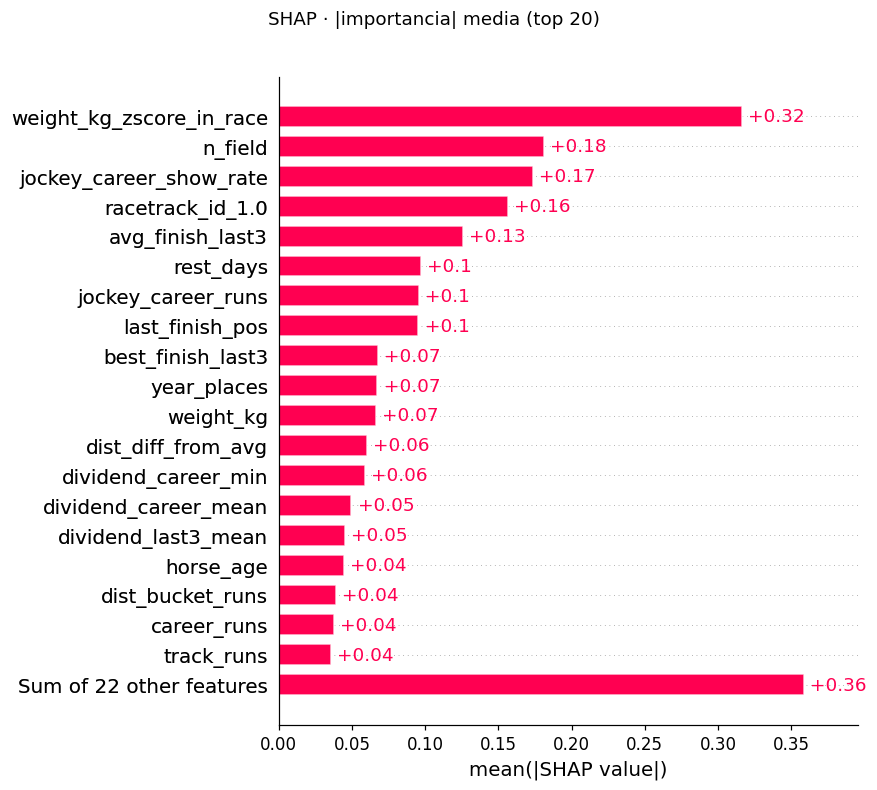

In [5]:
plt.figure()
shap.plots.bar(shap_values, max_display=20, show=False)
fig = plt.gcf()
fig.set_size_inches(8, 7)
fig.suptitle("SHAP · |importancia| media (top 20)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "09_shap_bar.png", bbox_inches="tight")
plt.show()

## 5. Beeswarm — signo + magnitud por feature

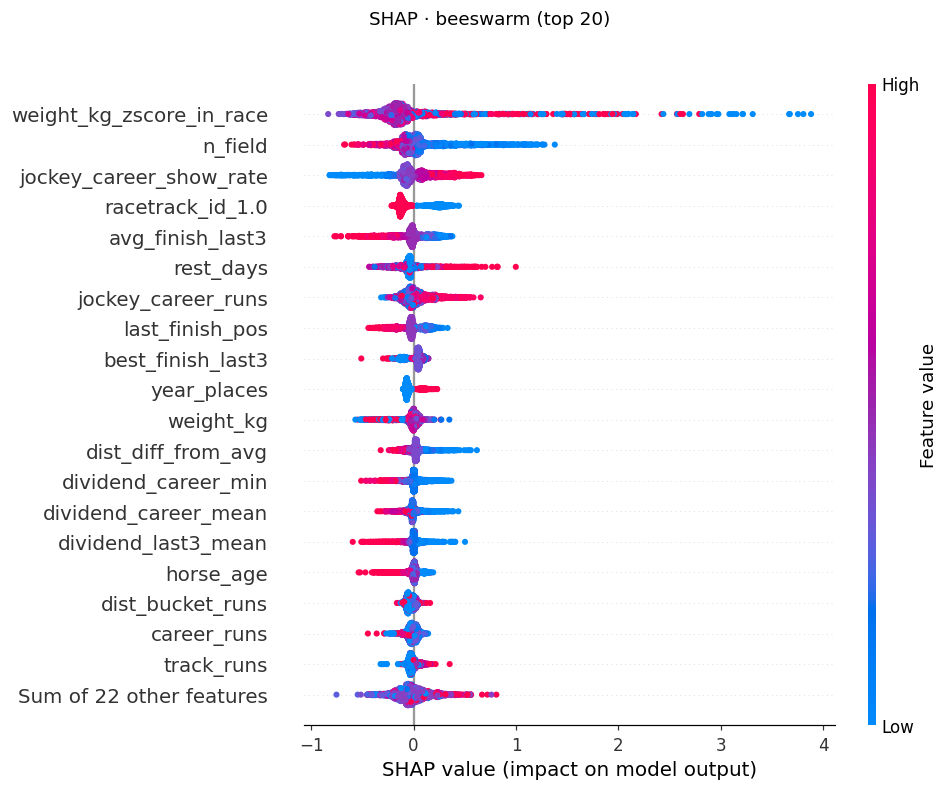

In [6]:
plt.figure()
shap.plots.beeswarm(shap_values, max_display=20, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 7)
fig.suptitle("SHAP · beeswarm (top 20)", y=1.02)
fig.tight_layout()
fig.savefig(FIG_DIR / "10_shap_beeswarm.png", bbox_inches="tight")
plt.show()

## 6. Dependence plots para las top-5 features

Top 5: ['weight_kg_zscore_in_race', 'n_field', 'jockey_career_show_rate', 'racetrack_id_1.0', 'avg_finish_last3']


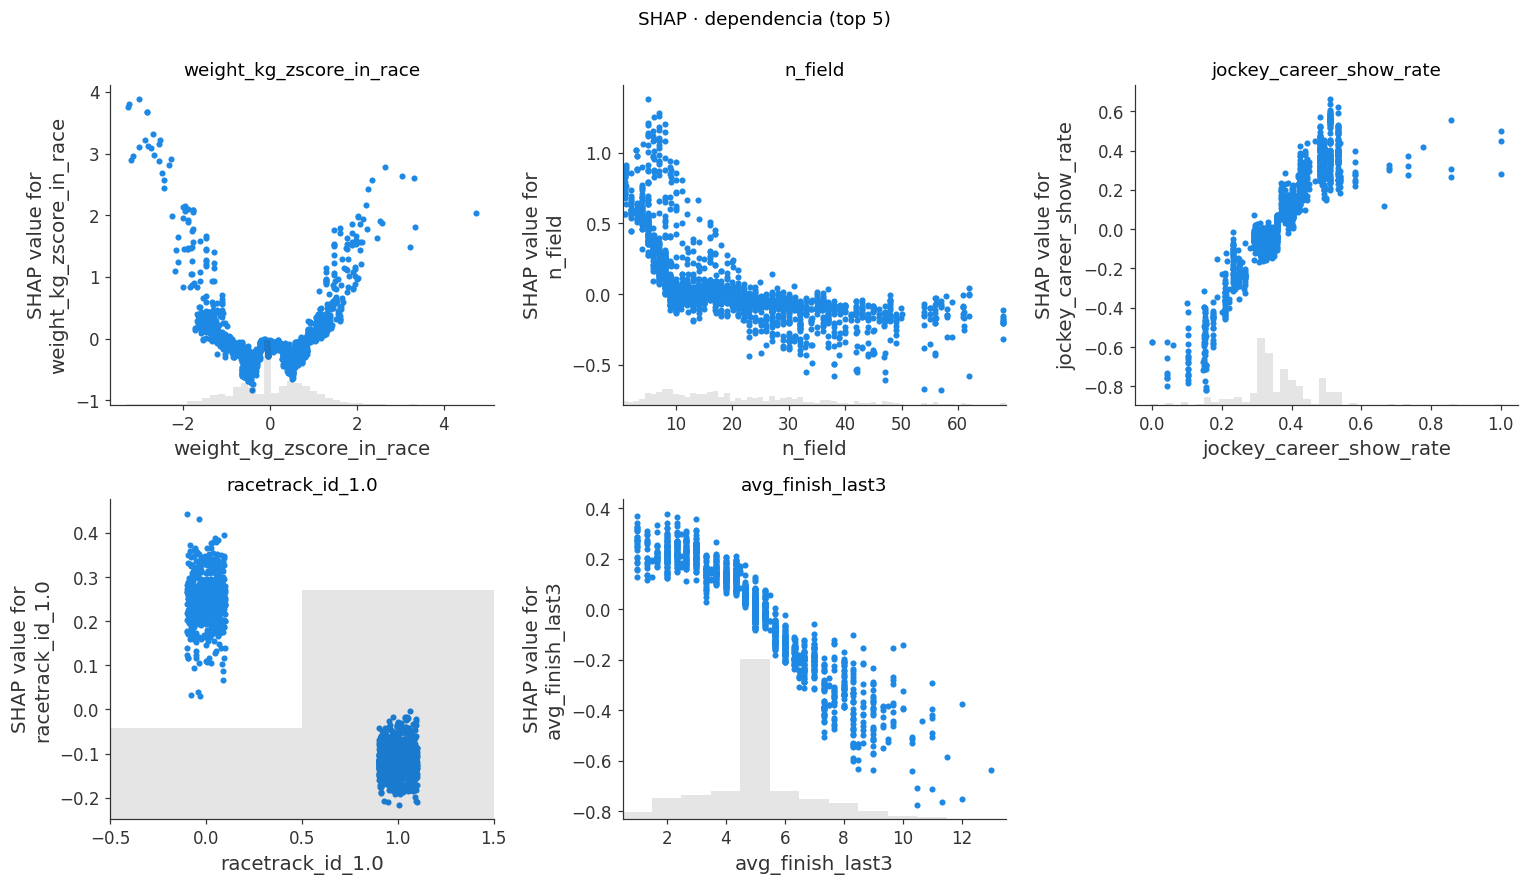

In [7]:
mean_abs = pd.Series(np.abs(shap_values.values).mean(axis=0), index=feat_names).sort_values(ascending=False)
top5 = mean_abs.head(5).index.tolist()
print("Top 5:", top5)

fig, axes = plt.subplots(2, 3, figsize=(14, 8))
for ax, feat in zip(axes.flat, top5):
    shap.plots.scatter(shap_values[:, feat], ax=ax, show=False)
    ax.set_title(feat)
axes.flat[-1].axis("off")
fig.suptitle("SHAP · dependencia (top 5)", y=1.00)
fig.tight_layout()
fig.savefig(FIG_DIR / "11_shap_dependence_top5.png", bbox_inches="tight")
plt.show()

## 7. Explicación local — un caballo concreto

Tomamos la predicción más confiada (`p` más alta) del sample y mostramos cómo cada feature
empuja el log-odds desde la base hacia la decisión final.

row_idx=9072 | p(in_trifecta)=0.983 | y=1
race_date         2024-12-08 00:00:00
horse_name                      PLUTO
jockey                  L. A. CÁCERES
racetrack_abbr                    MRÑ
distance_m                     2400.0
finish_pos                        1.0


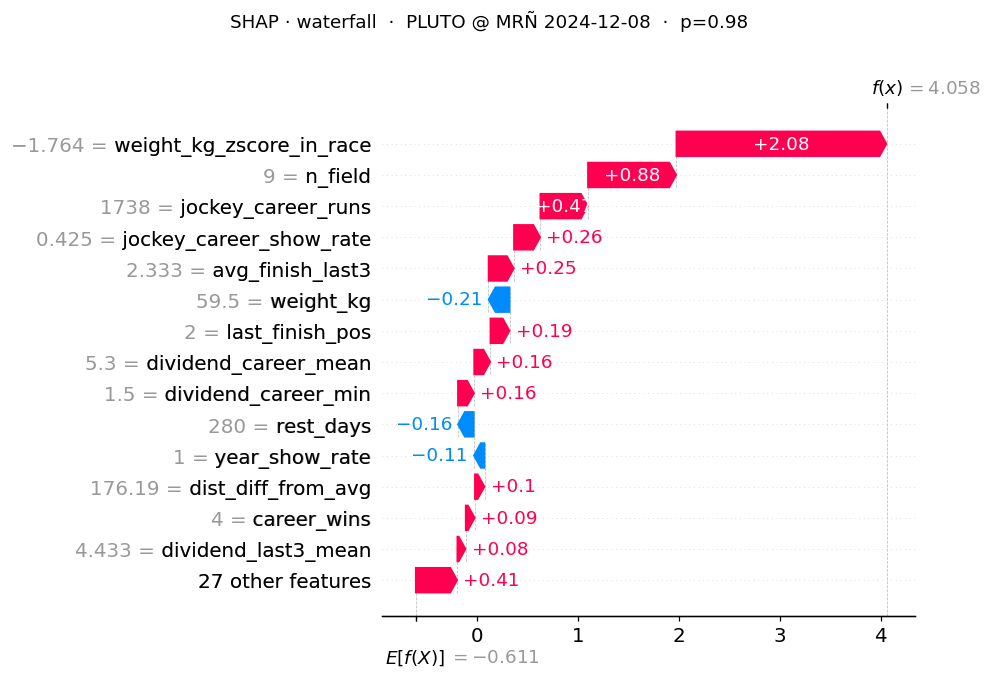

In [8]:
proba = clf.predict_proba(X_sample.values)[:, 1]
i = int(np.argmax(proba))
row_idx = X_sample.index[i]
ctx = test_df.loc[row_idx, ["race_date", "horse_name", "jockey", "racetrack_abbr", "distance_m", "finish_pos"]]
print(f"row_idx={row_idx} | p(in_trifecta)={proba[i]:.3f} | y={int(y_sample.iloc[i])}")
print(ctx.to_string())

plt.figure()
shap.plots.waterfall(shap_values[i], max_display=15, show=False)
fig = plt.gcf()
fig.set_size_inches(9, 6)
fig.suptitle(
    f"SHAP · waterfall  ·  {ctx['horse_name']} @ {ctx['racetrack_abbr']} {ctx['race_date'].date()}  ·  p={proba[i]:.2f}",
    y=1.02,
)
fig.tight_layout()
fig.savefig(FIG_DIR / "12_shap_waterfall_example.png", bbox_inches="tight")
plt.show()

## 8. Log a MLflow (opcional)

Adjunta la tabla de importancia y las 4 figuras como artifacts de una run nueva del experimento
`trifecta-classifier`. Si `MLFLOW_TRACKING_URI` no está seteado, escribe en `./mlruns`.

In [9]:
import os

import mlflow

mlflow.set_tracking_uri(os.getenv("MLFLOW_TRACKING_URI", "file:./mlruns"))
mlflow.set_experiment("trifecta-classifier")

imp_csv = FIG_DIR.parent / "shap_feature_importance.csv"
mean_abs.to_frame("mean_abs_shap").to_csv(imp_csv)

with mlflow.start_run(run_name="shap_explainability"):
    mlflow.log_param("sample_size", len(X_sample))
    mlflow.log_param("cutoff", str(cutoff.date()))
    mlflow.log_metric("top1_mean_abs_shap", float(mean_abs.iloc[0]))
    for fn in [
        "09_shap_bar.png",
        "10_shap_beeswarm.png",
        "11_shap_dependence_top5.png",
        "12_shap_waterfall_example.png",
    ]:
        mlflow.log_artifact(str(FIG_DIR / fn), artifact_path="shap")
    mlflow.log_artifact(str(imp_csv), artifact_path="shap")
    print("run_id:", mlflow.active_run().info.run_id)

2026/06/13 18:20:35 INFO mlflow.tracking.fluent: Experiment with name 'trifecta-classifier' does not exist. Creating a new experiment.


run_id: 18c43dee65864870b349d77c80a997d2


## 9. Lectura para el informe

Top features observadas en este sample (mean(|SHAP|), log-odds):

| # | Feature | mean(|SHAP|) | Lectura |
|---|---|---|---|
| 1 | `weight_kg_zscore_in_race` | 0.32 | Peso relativo dentro de la carrera. Cuánto más bajo el z, menos handicap respecto a sus rivales. |
| 2 | `n_field` | 0.18 | Tamaño del field. Carreras chicas elevan la prob. base de entrar a la trifecta. |
| 3 | `jockey_career_show_rate` | 0.17 | Señal cross-entity: track-record histórico del jockey con cualquier caballo. |
| 4 | `racetrack_id_1.0` | 0.16 | Indicadora de Maroñas — la trifecta es marginalmente más predecible en home track. |
| 5 | `avg_finish_last3` | 0.13 | Forma reciente del caballo. |

**Hallazgos para el informe:**

- **Las features `dividend_*` NO lideran** el ranking SHAP (caen entre #13 y #15) pese a haber sido el cambio que más movió la métrica entre v3 y v4. Coherente: SHAP mide contribución marginal por predicción, mientras que la mejora v3 → v4 vino de aportar **información ortogonal** que el modelo antes no tenía. Una feature puede mover ROC-AUC sin dominar el ranking de magnitud.
- **El peso relativo en la carrera (z-score) y el tamaño del field** son los drivers principales — features estructurales de la carrera, no del caballo. Confirma que el modelo aprovecha el contexto de carrera y no sólo memoriza caballos.
- **`jockey_career_show_rate` en el podio** valida la decisión de v4 de añadir señal cross-entity: el jockey importa tanto como las propias features históricas del caballo.
- **`post_position` no aparece** en el top porque es 100 % NaN en train (ver §8.6 de `CLAUDE.md`); el modelo nunca aprende a usarlo. Es una *feature muerta* en training y candidata a remover en el ejercicio de feature selection.

**Próximo paso:** `notebooks/03_feature_selection.ipynb` cruza este ranking con permutation importance y mutual information para decidir qué features podar.